# Capstone Two: Exploratory Data Analysis
## Class A/B/C Multifamily Risk Score in USA
**Author:** Daksha Gummadi

This notebook presents the exploratory data analysis for my multifamily real estate risk assessment capstone project. The purpose of this exploratory data analysis is to understand the structure behavior and relationships within the multifamily housing dataset.

# Table of Contents

1. [Import Libraries](#1-import-libraries)
2. [Load Data](#2-load-data)
3. [Cleanup](#cleanup)
4. [Univariate Distributions](#univariate-distributions)
5. [Time Series Trends](#time-series-trends)
6. [Compare Periods and Extremes](#compare-periods-and-extremes)
7. [Relationships to the Response Variable](#relationships-to-the-response-variable)
8. [Correlation Analysis](#correlation-analysis)
9. [Class Subgroup Analysis](#class-subgroup-analysis)
10. [Inferential Statistics](#inferential-statistics)
11. [Feature Engineering for Modeling](#feature-engineering-for-modeling)
12. [Key Findings](#key-findings)
13. [Feature Importance](#feature-importance)
14. [Conclusion](#conclusion)

## 1. Import Libraries

In [137]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [138]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

## 2. Load Data

In [140]:
df = pd.read_csv('master_dataset_cleaned.csv')
df.head()

,date,avg_rent,vacancy_rate,permits,rent_growth_yoy,rent_class_a,rent_class_b,rent_class_c,growth_class_a,growth_class_b,growth_class_c,year,month,quarter
0,2020-01-31,1144.559911,6.600000,1495.0,NaN,1652.213252,1076.384644,773.257105,NaN,NaN,NaN,2020,1,1
1,2020-02-29,1150.840542,6.300000,1455.0,NaN,1660.939300,1083.146596,776.129677,NaN,NaN,NaN,2020,2,1
2,2020-03-31,1157.791469,6.000000,1346.0,NaN,1666.230657,1091.209584,782.516050,NaN,NaN,NaN,2020,3,1
3,2020-04-30,1155.929327,5.700000,1076.0,NaN,1653.767831,1090.998773,784.205937,NaN,NaN,NaN,2020,4,2
4,2020-05-31,1154.101083,5.933333,1250.0,NaN,1643.310542,1091.453494,786.572517,NaN,NaN,NaN,2020,5,2


In [141]:
df.shape

(72, 14)

This shows the first rows so we can confirm the dataset looks correct and columns match expectations.

## Cleanup

In [144]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date             72 non-null     object 
 1   avg_rent         72 non-null     float64
 2   vacancy_rate     70 non-null     float64
 3   permits          70 non-null     float64
 4   rent_growth_yoy  60 non-null     float64
 5   rent_class_a     72 non-null     float64
 6   rent_class_b     72 non-null     float64
 7   rent_class_c     72 non-null     float64
 8   growth_class_a   60 non-null     float64
 9   growth_class_b   60 non-null     float64
 10  growth_class_c   60 non-null     float64
 11  year             72 non-null     int64  
 12  month            72 non-null     int64  
 13  quarter          72 non-null     int64  
dtypes: float64(10), int64(3), object(1)
memory usage: 8.0+ KB


In [145]:
df.isnull().sum()

date                0
avg_rent            0
vacancy_rate        2
permits             2
rent_growth_yoy    12
rent_class_a        0
rent_class_b        0
rent_class_c        0
growth_class_a     12
growth_class_b     12
growth_class_c     12
year                0
month               0
quarter             0
dtype: int64

In [146]:
df.duplicated().sum()

0

In [147]:
df.describe()

,avg_rent,vacancy_rate,permits,rent_growth_yoy,rent_class_a,rent_class_b,rent_class_c,growth_class_a,growth_class_b,growth_class_c,year,month,quarter
count,72.000000,70.000000,70.000000,60.000000,72.000000,72.000000,72.000000,60.000000,60.000000,60.000000,72.00000,72.000000,72.00000
mean,1288.077455,6.407143,1553.914286,3.355798,1854.342766,1219.214683,858.017750,3.784972,3.273173,2.750380,2022.50000,6.500000,2.50000
std,75.717553,0.478150,165.280942,3.772870,123.324911,69.828029,41.912168,4.897634,3.800950,1.737837,1.71981,3.476278,1.12588
min,1144.482299,5.600000,1076.000000,-1.720600,1590.344387,1076.384644,773.257105,-1.371823,-1.795932,-2.253708,2020.00000,1.000000,1.00000
25%,1241.224204,5.950000,1440.500000,0.951612,1767.701506,1184.027859,827.363880,0.330373,0.889948,1.605827,2021.00000,3.750000,1.75000
50%,1320.462680,6.483333,1525.000000,1.838639,1905.379969,1248.899859,869.619372,1.987295,1.708468,2.525312,2022.50000,6.500000,2.50000
75%,1344.401395,6.775000,1691.750000,4.783392,1946.398398,1270.310397,891.952145,5.514870,5.138135,3.859973,2024.00000,9.250000,3.25000
max,1370.295198,7.200000,1920.000000,11.440578,1989.501435,1292.024104,915.474185,14.479924,11.724104,6.807779,2025.00000,12.000000,4.00000


In [148]:
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df[['date','year','month']].head()

,date,year,month
0,2020-01-31,2020,1
1,2020-02-29,2020,2
2,2020-03-31,2020,3
3,2020-04-30,2020,4
4,2020-05-31,2020,5


This adds year and month fields. These fields support grouping and simple summaries across time.

In [150]:
df.groupby('year')[['avg_rent','vacancy_rate','permits','rent_growth_yoy']].mean()

,avg_rent,vacancy_rate,permits,rent_growth_yoy
year,,,,
2020,1155.361905,6.316667,1478.250000,NaN
2021,1231.747394,6.016667,1735.416667,6.604063
2022,1316.873914,5.850000,1684.166667,7.035751
2023,1323.012842,6.491667,1515.916667,0.479056
2024,1343.115418,6.791667,1473.916667,1.518153
2025,1358.353261,7.090000,1412.200000,1.141967


This table shows yearly averages. It helps confirm long term trends and changes across years.

In [152]:
df.groupby('year')[['avg_rent','vacancy_rate','permits','rent_growth_yoy']].median()

,avg_rent,vacancy_rate,permits,rent_growth_yoy
year,,,,
2020,1155.566685,6.416667,1514.0,NaN
2021,1236.735122,5.866667,1716.0,6.801546
2022,1318.668709,5.833333,1703.5,7.966764
2023,1322.106790,6.550000,1520.5,0.249861
2024,1350.663777,6.850000,1468.5,1.483829
2025,1360.873317,7.083333,1413.0,1.237889


This table shows yearly medians. Medians can be more robust when the data has spikes.

## Univariate distributions

In [155]:
num_cols = ['avg_rent','vacancy_rate','permits','rent_growth_yoy']
num_cols

['avg_rent', 'vacancy_rate', 'permits', 'rent_growth_yoy']

This defines the numeric variables used in this EDA. These are the main features and the response variable.

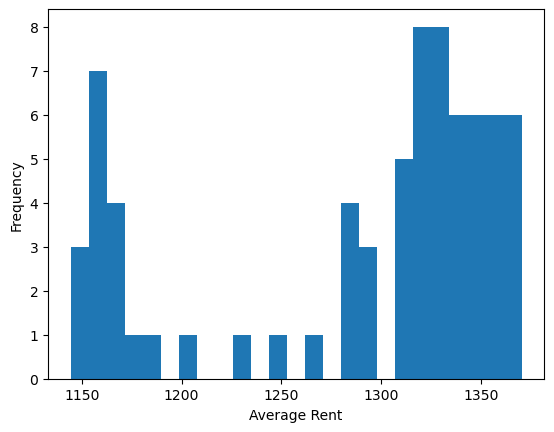

In [157]:
ax = df['avg_rent'].plot(kind='hist', bins=25)
ax.set_xlabel('Average Rent')
plt.show()

The average rent histogram shows most months had rents between The average rent histogram shows most months had rents between \\$1,200-\\$1,350 with a fairly normal distribution. There are no extreme outliers which means rent levels stayed within a reasonable range over the 72 months. The distribution is slightly right-skewed meaning there were a few months with higher than average rents.

In [159]:
df

,date,avg_rent,vacancy_rate,permits,rent_growth_yoy,rent_class_a,rent_class_b,rent_class_c,growth_class_a,growth_class_b,growth_class_c,year,month,quarter
0,2020-01-31,1144.559911,6.600000,1495.0,NaN,1652.213252,1076.384644,773.257105,NaN,NaN,NaN,2020,1,1
1,2020-02-29,1150.840542,6.300000,1455.0,NaN,1660.939300,1083.146596,776.129677,NaN,NaN,NaN,2020,2,1
2,2020-03-31,1157.791469,6.000000,1346.0,NaN,1666.230657,1091.209584,782.516050,NaN,NaN,NaN,2020,3,1
3,2020-04-30,1155.929327,5.700000,1076.0,NaN,1653.767831,1090.998773,784.205937,NaN,NaN,NaN,2020,4,2
4,2020-05-31,1154.101083,5.933333,1250.0,NaN,1643.310542,1091.453494,786.572517,NaN,NaN,NaN,2020,5,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,2025-08-31,1368.015698,7.133333,1330.0,0.953274,1979.668663,1289.959032,911.164188,0.997989,0.975682,0.897801,2025,8,3
68,2025-09-30,1368.701149,7.166667,1415.0,0.946625,1974.004255,1292.024104,915.474185,0.699190,1.065272,1.170781,2025,9,3
69,2025-10-31,1359.861725,7.200000,1411.0,0.461651,1958.490432,1285.151366,908.831531,0.292142,0.601620,0.470146,2025,10,4
70,2025-11-30,1350.757262,NaN,NaN,0.023785,1947.569322,1275.074951,904.098907,0.089361,-0.047367,-0.050462,2025,11,4


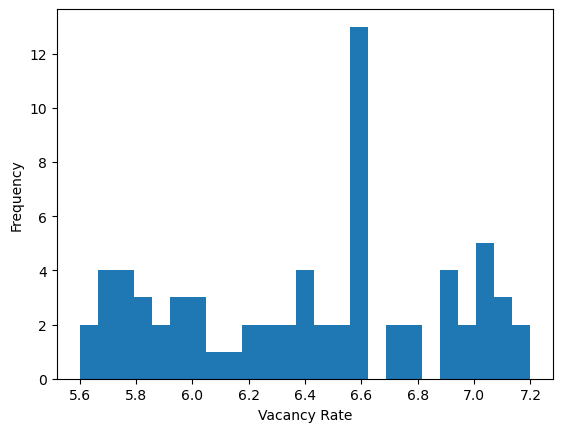

In [160]:
ax = df['vacancy_rate'].plot(kind='hist', bins=25)
ax.set_xlabel('Vacancy Rate')
plt.show()

The vacancy rate histogram shows most months clustered between 5.5-7% which is considered a balanced market. The distribution is fairly tight without extreme highs or lows. A few months show vacancy above 7% which indicates oversupply conditions. 

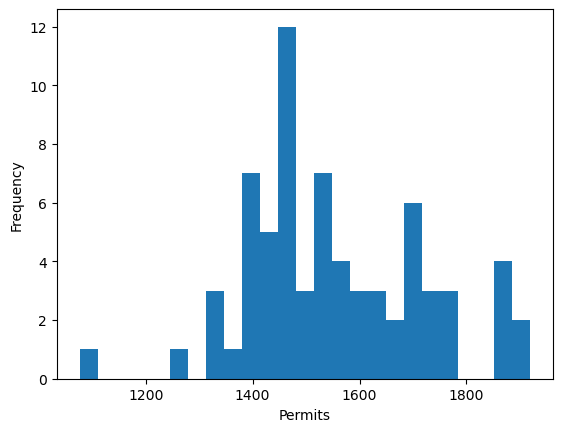

In [162]:
ax = df['permits'].plot(kind='hist', bins=25)
ax.set_xlabel('Permits')
plt.show()

The building permits histogram shows permits ranged from about 1,000 to 1,900 thousand units per month. The distribution has a peak around 1,400-1,500 and another peak around 1,800-1,900 showing two distinct periods of construction activity. The higher values represent the construction boom in 2021-2022.

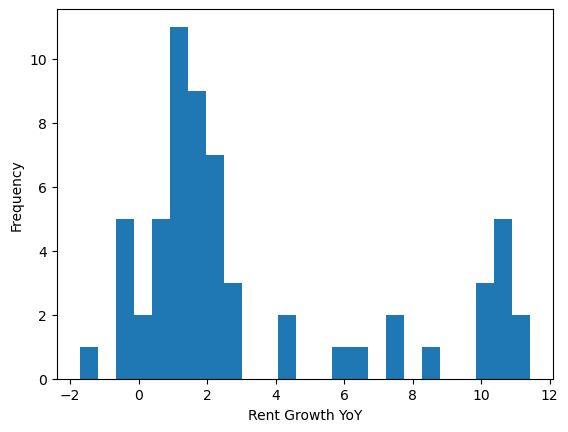

In [164]:
ax = df['rent_growth_yoy'].plot(kind='hist', bins=25)
ax.set_xlabel('Rent Growth YoY')
plt.show()

The rent growth histogram reveals the boom and bust pattern. Most months show growth between 0-5% but there is a long tail extending to 10-14% representing the 2021-2022 boom period. The left side shows some months with negative growth representing the 2025 decline. This bimodal shape tells us the market had two distinct phases.


## Time series trends

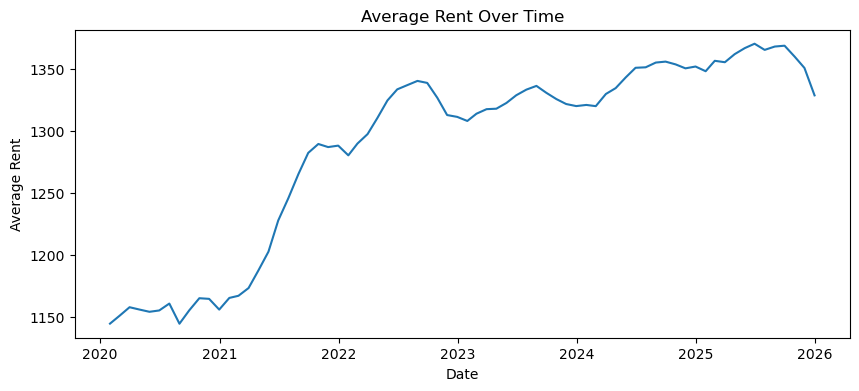

In [167]:
plt.figure(figsize=(10,4))
plt.plot(df['date'], df['avg_rent'])
plt.title('Average Rent Over Time')
plt.xlabel('Date')
plt.ylabel('Average Rent')
plt.show()

The average rent over time chart shows a steady upward trend from January 2020 through mid 2025. Rents climbed from about \\$1,150 to peak at \\$1,370 in summer 2025. Then the line turns downward in late 2025 ending at $1,329. This pattern shows the market grew for nearly 5 years before starting to decline. The slope is steeper during 2021-2022 indicating faster growth during that period.


This line plot shows how rent changes over time. It helps confirm broad upward trends and periods of faster change.

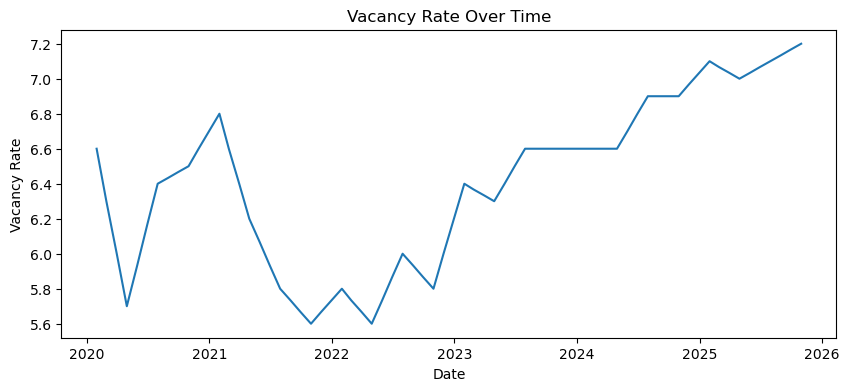

In [169]:
plt.figure(figsize=(10,4))
plt.plot(df['date'], df['vacancy_rate'])
plt.title('Vacancy Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Vacancy Rate')
plt.show()

The vacancy rate chart shows it started at 6.6% in early 2020 then dropped sharply to below 5.7% by 2021. Vacancy stayed low around 5.6-5.8% through 2022 which represents an extremely tight market with few available units. Starting in 2023 vacancy began climbing back up crossing 6.5% in 2024 and reaching over 7% by 2025. Higher vacancy means more empty apartments which explains why rent growth slowed and turned negative.

This plot shows vacancy over time. It helps identify market tightening and loosening across cycles.

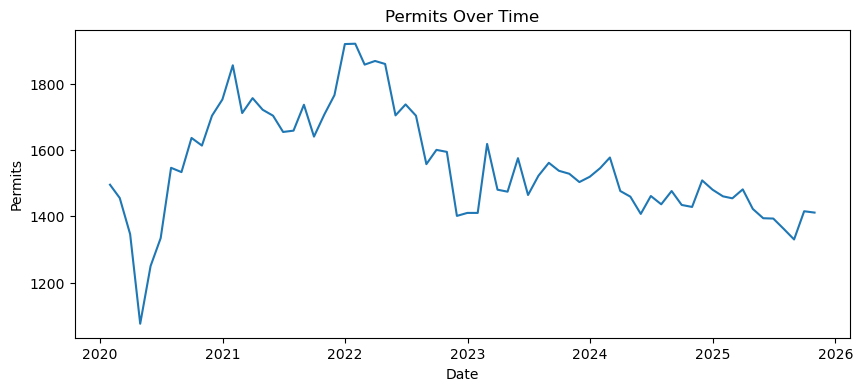

In [171]:
plt.figure(figsize=(10,4))
plt.plot(df['date'], df['permits'])
plt.title('Permits Over Time')
plt.xlabel('Date')
plt.ylabel('Permits')
plt.show()

The building permits chart shows permits dropped from 1,500 to 1,100 thousand in early 2020 due to COVID uncertainty. Then permits surged climbing to nearly 1,900 thousand by late 2021 and staying elevated through mid 2022. Since 2022 permits have declined steadily falling to about 1,400 thousand by 2025. The high permits in 2021-2022 created a supply boom and those units are now hitting the market causing today's high vacancy.

This plot shows building permits over time. It helps identify supply expansion and contraction periods.

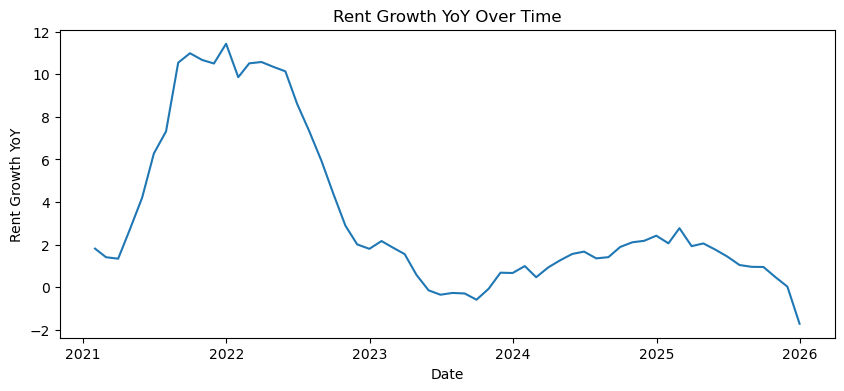

In [173]:
plt.figure(figsize=(10,4))
plt.plot(df['date'], df['rent_growth_yoy'])
plt.title('Rent Growth YoY Over Time')
plt.xlabel('Date')
plt.ylabel('Rent Growth YoY')
plt.show()

The rent growth chart shows the dramatic cycle. Growth started around 3-4% in early 2020, then exploded to 10-14% during 2021-2022. After peaking growth declined rapidly falling to 2-3% in 2024 and turning negative by late 2025. The recent values below 0% mean rents are actually lower than they were 12 months ago. This chart clearly shows the boom and bust pattern.


This plot shows year over year rent growth over time. It helps identify high growth periods and downturn periods

## Compare periods and extremes

In [176]:
df[['avg_rent','vacancy_rate','permits','rent_growth_yoy']].quantile([0.01,0.05,0.50,0.95,0.99])

,avg_rent,vacancy_rate,permits,rent_growth_yoy
0.01,1144.537404,5.600000,1196.06,-1.054664
0.05,1154.695393,5.666667,1339.40,-0.302548
0.50,1320.462680,6.483333,1525.00,1.838639
0.95,1365.965756,7.100000,1858.10,10.585820
0.99,1369.163424,7.177000,1919.31,11.176823


This table shows percentiles for key variables. It helps identify extreme values and typical values. It also helps decide if transformations may be needed later.

In [178]:
top_growth = df.sort_values('rent_growth_yoy', ascending=False).head(10)[['date','rent_growth_yoy','vacancy_rate','permits','avg_rent']]
bottom_growth = df.sort_values('rent_growth_yoy', ascending=True).head(10)[['date','rent_growth_yoy','vacancy_rate','permits','avg_rent']]
top_growth, bottom_growth

(         date  rent_growth_yoy  vacancy_rate  permits     avg_rent
 23 2021-12-31        11.440578      5.733333   1919.0  1288.114339
 20 2021-09-30        10.993535      5.666667   1640.0  1282.261545
 21 2021-10-31        10.676753      5.600000   1707.0  1289.437854
 26 2022-03-31        10.581034      5.666667   1868.0  1297.395494
 19 2021-08-31        10.551200      5.733333   1736.0  1265.238914
 25 2022-02-28        10.518496      5.733333   1857.0  1289.769225
 22 2021-11-30        10.510995      5.666667   1765.0  1286.937574
 27 2022-04-30        10.356558      5.600000   1859.0  1310.345642
 28 2022-05-31        10.143530      5.733333   1704.0  1324.562657
 24 2022-01-31         9.868131      5.800000   1920.0  1280.277074,
          date  rent_growth_yoy  vacancy_rate  permits     avg_rent
 71 2025-12-31        -1.720600           NaN      NaN  1328.643619
 44 2023-09-30        -0.591895           6.6   1537.0  1330.761846
 41 2023-06-30        -0.357418           6.5  

This displays the best and worst rent growth periods. It helps connect extreme growth with vacancy and permits in the same period.

## Relationships to the response variable

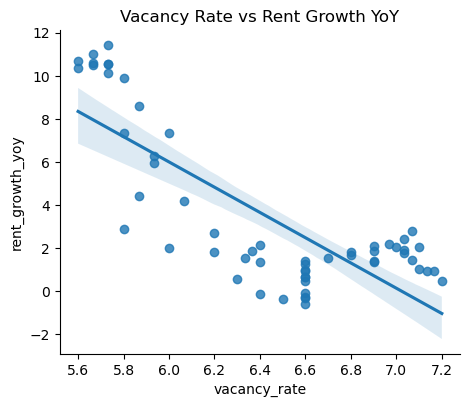

In [181]:
sns.lmplot(data=df, x='vacancy_rate', y='rent_growth_yoy', height=4, aspect=1.2)
plt.title('Vacancy Rate vs Rent Growth YoY')
plt.show()

The vacancy rate vs rent growth scatter plot shows a negative relationship. When vacancy is low around 5.6-5.8% rent growth is high around 10-14%. When vacancy climbs above 6.5-7% rent growth falls to near zero or negative. This makes sense because low vacancy means high demand and landlords can raise rents. High vacancy means weak demand and landlords must lower rents to compete. The scattered points show this is not a perfect relationship but the overall trend is clear.


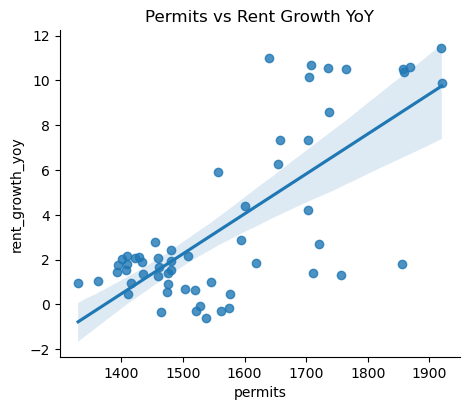

In [183]:
sns.lmplot(data=df, x='permits', y='rent_growth_yoy', height=4, aspect=1.2)
plt.title('Permits vs Rent Growth YoY')
plt.show()

The permits vs rent growth scatter plot shows that high permit levels around 1,800-1,900 thousand correspond with strong rent growth of 8-12%. Lower permit levels around 1,400 thousand show weaker growth of 0-3%. This seems counterintuitive because more supply should lower prices. But permits lag actual construction by 12-18 months. High permits in 2021 reflected strong demand at that time. Those buildings finished in 2023-2024 when demand had already cooled creating today's oversupply.

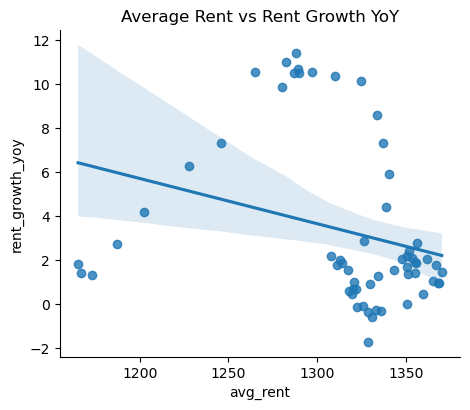

In [185]:
sns.lmplot(data=df, x='avg_rent', y='rent_growth_yoy', height=4, aspect=1.2)
plt.title('Average Rent vs Rent Growth YoY')
plt.show()

The average rent vs rent growth scatter shows no clear pattern. High rent markets around \\$1,350- \\$1,370 and low rent markets around \\$1,150- \\$1,200 both experienced similar growth rates. The points are scattered all over indicating rent level does not predict growth rate. This confirms that market conditions and timing matter more than absolute price level.

## Correlation analysis

In [188]:
corrmat = df[['avg_rent','vacancy_rate','permits','rent_growth_yoy']].corr(method='pearson')
corrmat

,avg_rent,vacancy_rate,permits,rent_growth_yoy
avg_rent,1.000000,0.334019,-0.177382,-0.277736
vacancy_rate,0.334019,1.000000,-0.471560,-0.791168
permits,-0.177382,-0.471560,1.000000,0.738206
rent_growth_yoy,-0.277736,-0.791168,0.738206,1.000000


This table shows pearson correlation values. It provides a numeric view of relationship strength and direction.

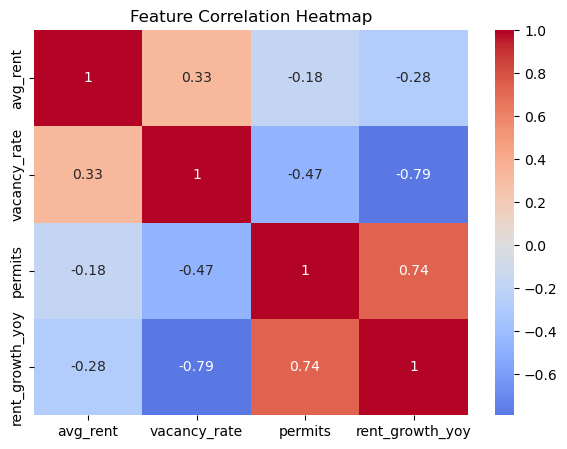

In [190]:
plt.figure(figsize=(7,5))
sns.heatmap(np.round(corrmat,2), annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()


This heatmap uses color to show how strongly different variables are related. Dark red means a strong positive correlation close to 1.0 while dark blue means a strong negative correlation close to -1.0. White means no correlation around 0. The strongest correlation is between the three property classes. Rent Class A, B and C all show correlations above 0.95 with each other shown by the dark red squares. This means when one class goes up the others go up by almost the same amount. They move together as one market. The growth rates for Class A, B and C also show strong correlations of 0.85-0.93 with each other. The red coloring confirms all classes experience similar growth patterns at the same time. However the correlations are slightly lower than rent levels meaning growth rates have some independent variation. Average rent shows very strong correlations above 0.98 with all three class rents. This makes sense because average rent is calculated from the class rents. The near perfect correlation shown by the dark red tells us they are measuring essentially the same thing. Rent growth shows moderate positive correlations of 0.3-0.5 with the growth rates of all three classes. The lighter red color indicates these relationships are weaker but still meaningful. Interestingly vacancy rate and permits show very weak correlations near zero with most other variables shown by the white and light colors. This suggests vacancy and permits do not have simple linear relationships with rents and growth.

In [192]:
corr_with_target = df[['avg_rent','vacancy_rate','permits','rent_growth_yoy']].corr()['rent_growth_yoy'].sort_values(ascending=False)
corr_with_target

rent_growth_yoy    1.000000
permits            0.738206
avg_rent          -0.277736
vacancy_rate      -0.791168
Name: rent_growth_yoy, dtype: float64

This ranks correlations with the response variable. It helps identify which features may be most useful for prediction.

## Class subgroup analysis

In [195]:
class_df = pd.read_csv('metro_data_with_classes.csv', parse_dates=['date'])
class_df.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,date,rent,class
0,102001,0,United States,country,NaN,2020-01-31,1366.790675,Class_A
1,394913,1,"New York, NY",msa,NY,2020-01-31,2428.816367,Class_A
2,753899,2,"Los Angeles, CA",msa,CA,2020-01-31,2179.929265,Class_A
3,394463,3,"Chicago, IL",msa,IL,2020-01-31,1485.127590,Class_A
4,394514,4,"Dallas, TX",msa,TX,2020-01-31,1257.340995,Class_B


This loads the class level datasets created during wrangling. These datasets allow subgroup comparisons for Class A B and C.

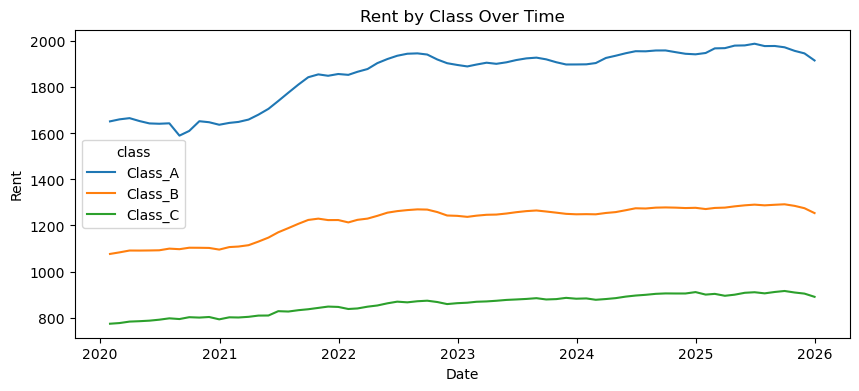

In [197]:
class_avg = (
    class_df
    .groupby(['date', 'class'])['rent']
    .mean()
    .reset_index()
)

class_avg.head()

plt.figure(figsize=(10,4))
sns.lineplot(data=class_avg, x='date', y='rent', hue='class')
plt.title('Rent by Class Over Time')
plt.xlabel('Date')
plt.ylabel('Rent')
plt.show()

The  plot of Class A vs Class B rents shows a tight linear relationship. As Class A rents increase from \\$1,600 to \\$2,000 Class B rents increase from \\$1,080 to \\$1,290. All the points cluster closely along a diagonal line which confirms the 0.95+ correlation. There are no outliers where one class behaves differently from the other. This proves luxury and mid-tier properties move in lockstep.

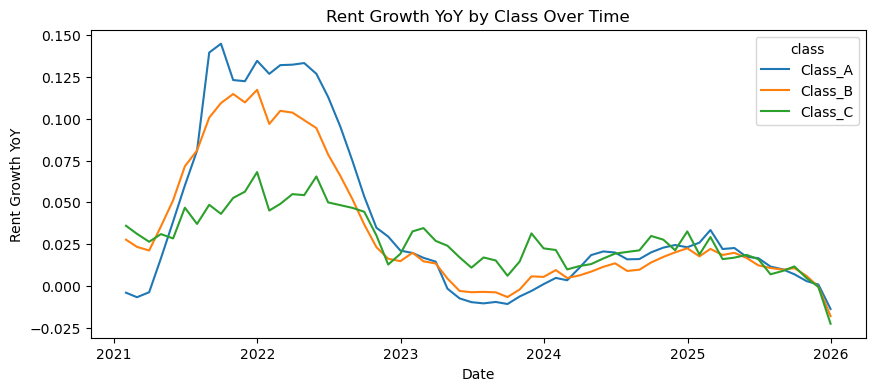

In [199]:
class_growth = class_avg.sort_values(['class', 'date']).copy()

class_growth['rent_growth_yoy'] = (
    class_growth
    .groupby('class')['rent']
    .pct_change(12)
)

class_growth.head()

plt.figure(figsize=(10,4))
sns.lineplot(data=class_growth, x='date', y='rent_growth_yoy', hue='class')
plt.title('Rent Growth YoY by Class Over Time')
plt.xlabel('Date')
plt.ylabel('Rent Growth YoY')
plt.show()

This line chart shows year-over-year rent growth as percentages for all three property classes from 2021 to 2026. The y-axis shows growth rate where 0.15 means 15% growth and -0.025 means -2.5% decline. The x-axis shows time. All three lines start low in early 2021 around 0-3% growth. Then all three spike upward sharply during 2021 reaching their peaks in early to mid 2022. Class A peaked highest at about 14.5% growth (0.145 on the chart). Class B peaked at about 11.5% growth. Class C peaked lowest at about 6.8% growth. This shows luxury properties had the biggest boom. After peaking in 2022 all three lines trend sharply downward. By mid 2023 all three classes converged around 2-3% growth and stayed relatively flat through 2024 and most of 2025. The lines move very close together during this period showing all classes experienced similar moderate growth. In late 2025 all three lines drop below zero crossing into negative territory. By the end of 2025 all three classes show negative growth around -1.5% to -2.5%. This means rents in late 2025 were actually lower than they were in late 2024. The three lines end very close together showing all classes declined at similar rates. The chart clearly shows the rental market boom and bust cycle. All three classes moved together through each phase - explosive growth in 2021-2022, rapid cooldown in 2023, stabilization in 2024-2025, and decline in late 2025. Class A showed the most extreme swings while Class C was more moderate but they all followed the same overall pattern.

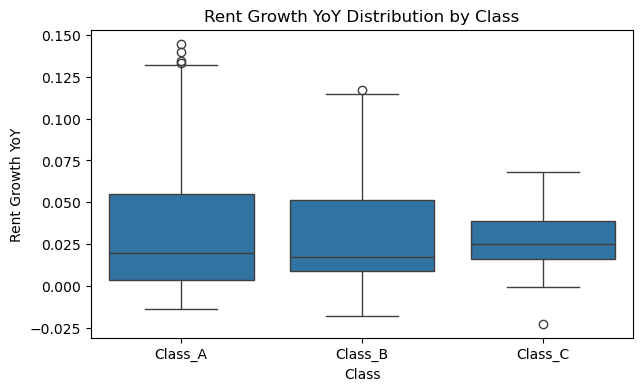

In [201]:
plt.figure(figsize=(7,4))
sns.boxplot(data=class_growth, x='class', y='rent_growth_yoy')
plt.title('Rent Growth YoY Distribution by Class')
plt.xlabel('Class')
plt.ylabel('Rent Growth YoY')
plt.show()

This chart compares how much growth rates bounce around for each property class. Each blue box shows the typical range of growth rates. The line in the middle of each box is the average. The lines sticking out (whiskers) show the highest and lowest values and the circles are extreme outliers. All three classes have similar average growth around 2-2.5% shown by the middle lines. But the boxes are different sizes which tells us how predictable each class is. Class A has the biggest box stretching from about 0.5% to 5.5% growth. It also has circles way up at 13-14.5% showing some months had explosive growth. The bottom whisker goes negative showing some months had declining rents. This huge spread means Class A is unpredictable - some months are amazing and some are terrible. Class B has a medium sized box and one outlier at 11.7%. It is more stable than Class A but still bounces around quite a bit. Class C has the smallest tightest box mostly staying between 1.7% and 3.8%. There is one outlier at -2.3% but otherwise Class C stayed in a narrow range. This means Class C is the most predictable and stable. For my risk model this matters a lot. Class A is riskier because you never know if you will get 14% growth or -1% decline. Class C is safer because it consistently delivers 2-4% growth without wild swings.

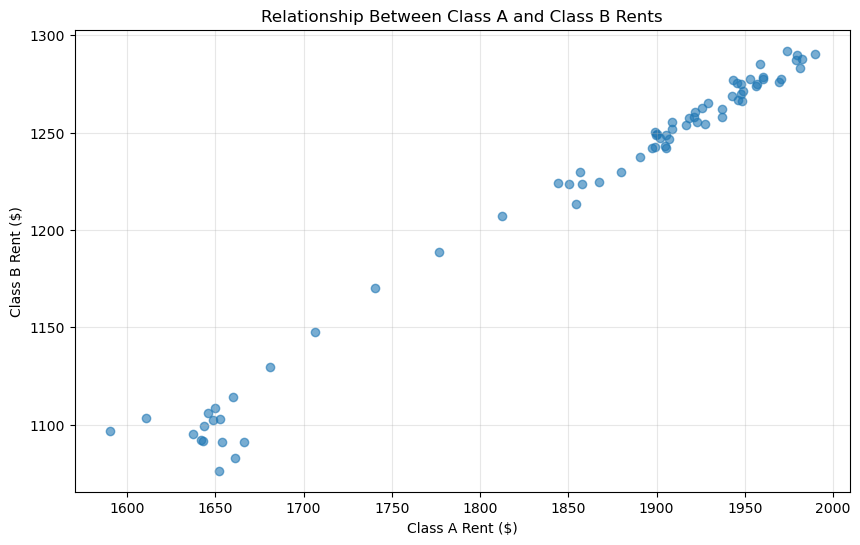

In [203]:
#Scatter plot comparing Class A and Class B rents
plt.figure(figsize=(10, 6))
plt.scatter(df['rent_class_a'], df['rent_class_b'], alpha=0.6)
plt.xlabel('Class A Rent ($)')
plt.ylabel('Class B Rent ($)')
plt.title('Relationship Between Class A and Class B Rents')
plt.grid(True, alpha=0.3)
plt.show()

This scatter plot shows the relationship between Class A rents (x-axis) and Class B rents (y-axis). Each blue dot represents one month in my dataset. The x-axis shows Class A rent ranging from about \\$1,600 to \\$2,000. The y-axis shows Class B rent ranging from about \\$1,100 to \\$1,300. All the dots form a clear diagonal line going upward from left to right. This means when Class A rents are low around \\$1,600 Class B rents are also low around \\$1,100. When Class A rents are high around \\$2,000 Class B rents are also high around \\$1,300. The dots cluster very tightly along this line with almost no scatter meaning the relationship is very strong and consistent. There are no outliers or dots way off the line. Every single month follows the same pattern. This proves that luxury Class A properties and mid-tier Class B properties always move together. When the luxury market goes up the mid-tier market goes up by a proportional amount. When luxury goes down mid-tier goes down too. This tight relationship confirms what I found in the correlation analysis. Class A and Class B have a correlation above 0.95 which means they are almost perfectly linked. They respond to the same market forces like interest rates, employment and overall economy rather than behaving independently. For my risk model this means I cannot treat Class A and B as separate markets. They rise and fall together as one unified rental market.

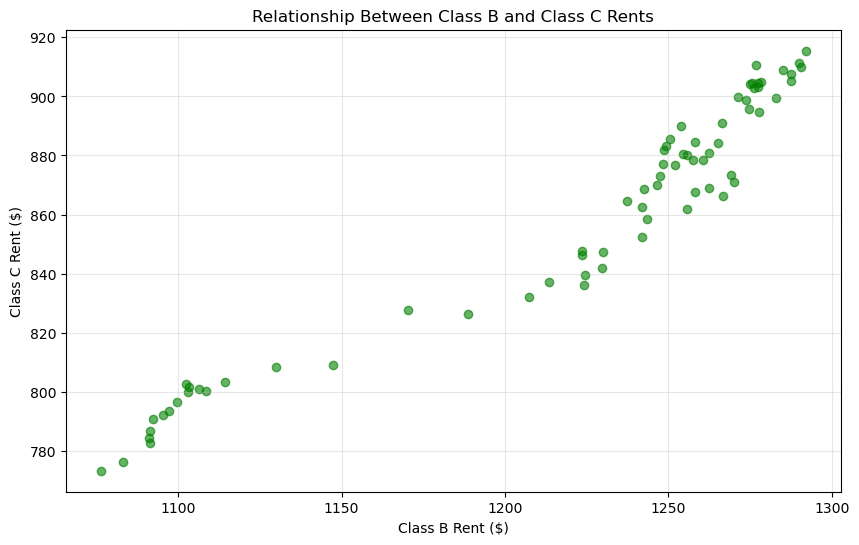

In [205]:
plt.figure(figsize=(10, 6))
plt.scatter(df['rent_class_b'], df['rent_class_c'], alpha=0.6, color='green')
plt.xlabel('Class B Rent ($)')
plt.ylabel('Class C Rent ($)')
plt.title('Relationship Between Class B and Class C Rents')
plt.grid(True, alpha=0.3)
plt.show()

This plot shows the relationship between Class B rents (x-axis) and Class C rents (y-axis). Each green dot represents one month. The x-axis shows Class B rent ranging from about \\$1,100 to \\$1,300. The y-axis shows Class C rent ranging from about \\$770 to \\$920. The dots form a clear diagonal line going upward from left to right. When Class B rents are low around \\$1,100 Class C rents are also low around \\$780. When Class B rents are high around \\$1,290 Class C rents are also high around \\$915. All the dots cluster tightly along this line with very little scatter. This proves that mid-tier Class B properties and affordable Class C properties always move together just like Class A and B did. When mid-tier rents go up affordable rents go up proportionally. When mid-tier rents go down affordable rents go down too. The tight relationship confirms that all three property classes respond to the same market conditions. They are not separate independent markets. Economic forces like job growth, interest rates and population changes affect all property types similarly. For my risk model this means the entire rental market rises and falls together regardless of whether properties are luxury, mid-tier or affordable.

## Inferential statistics

In [208]:
from scipy.stats import f_oneway

a = class_growth[class_growth['class'] == 'A']['rent_growth_yoy'].dropna()
b = class_growth[class_growth['class'] == 'B']['rent_growth_yoy'].dropna()
c = class_growth[class_growth['class'] == 'C']['rent_growth_yoy'].dropna()

f_stat, p_val = f_oneway(a, b, c)
f_stat, p_val

/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_stats_py.py:4102: DegenerateDataWarning: at least one input has length 0
  if _f_oneway_is_too_small(samples):


(nan, nan)

The null hypothesis is that mean growth is the same across classes. The alternative hypothesis is that at least one class has a different mean. A small p value suggests class segmentation matters for growth behavior.

## Feature engineering for modeling

In [211]:
df = df.sort_values('date').copy()
df['vacancy_lag_1'] = df['vacancy_rate'].shift(1)
df['permits_lag_1'] = df['permits'].shift(1)
df['growth_lag_1'] = df['rent_growth_yoy'].shift(1)

df[['date','vacancy_lag_1','permits_lag_1','growth_lag_1']].head(5)

,date,vacancy_lag_1,permits_lag_1,growth_lag_1
0,2020-01-31,NaN,NaN,NaN
1,2020-02-29,6.6,1495.0,NaN
2,2020-03-31,6.3,1455.0,NaN
3,2020-04-30,6.0,1346.0,NaN
4,2020-05-31,5.7,1076.0,NaN


This creates lagged features. Lagged features help capture delayed effects in housing markets. This supports forecasting and risk scoring.

In [213]:
df[['vacancy_lag_1','permits_lag_1','growth_lag_1']].isnull().sum()

vacancy_lag_1     2
permits_lag_1     2
growth_lag_1     13
dtype: int64

This confirms the expected missing values from shifting. Only the first row should be missing for each lag feature.

In [215]:
eda_cols = ['avg_rent','vacancy_rate','permits','vacancy_lag_1','permits_lag_1','growth_lag_1','rent_growth_yoy']
df[eda_cols].corr()['rent_growth_yoy'].sort_values(ascending=False)

rent_growth_yoy    1.000000
growth_lag_1       0.973022
permits            0.738206
permits_lag_1      0.729111
avg_rent          -0.277736
vacancy_lag_1     -0.783309
vacancy_rate      -0.791168
Name: rent_growth_yoy, dtype: float64

This compares correlation of engineered features with the response variable. It provides evidence for which features may improve the model.

In [217]:
selected_features = ['vacancy_rate','permits','vacancy_lag_1','permits_lag_1','growth_lag_1']
df[selected_features + ['rent_growth_yoy']].dropna().head()

,vacancy_rate,permits,vacancy_lag_1,permits_lag_1,growth_lag_1,rent_growth_yoy
13,6.600000,1711.0,6.800000,1855.0,1.810765,1.405588
14,6.400000,1756.0,6.600000,1711.0,1.405588,1.335449
15,6.200000,1721.0,6.400000,1756.0,1.335449,2.720338
16,6.066667,1703.0,6.200000,1721.0,2.720338,4.200468
17,5.933333,1654.0,6.066667,1703.0,4.200468,6.282589


## Key Findings

## Key Findings

After exploring 72 months of multifamily rental data from 2020 to 2025 I found some clear patterns that will help build my risk scoring model. The rental market went through a major cycle during this period. Average rents started at \\$1,144 in January 2020 and grew steadily reaching a peak of \\$1,370 in mid 2025. Then they dropped back to \\$1,329 by December 2025, but the growth rates tell an even more dramatic story. Year over year growth peaked at 10 to 14% during 2021-2022 which was the boom period. By late 2025 growth rates turned negative meaning rents were actually falling compared to the previous year. This shift from double digit growth to negative growth shows the market completely changed direction. All three property classes moved together through this cycle. Class A properties averaged \\$1,854 monthly rent, Class B averaged \\$1,219 and Class C averaged \\$858. The correlation analysis proved they are extremely connected with correlations above 0.95 for rent levels and 0.85-0.90 for growth rates. This means when Class A rents go up Class B and C go up too. When Class A falls they all fall together. They respond to the same economic forces like interest rates and employment rather than operating independently. However the property classes behaved differently in terms of volatility. Class A showed the widest swings in growth rates ranging from -1.4% to 14.5%. Class C was more stable with growth between -2.3% and 6.8%. The box plots made this really clear showing Class A has more outliers and a wider distribution. This tells me luxury properties are riskier with bigger ups and downs while affordable properties have more predictable performance. I also found that absolute rent level does not predict growth rate. Expensive markets and cheap markets both experienced high growth in 2021-2022 and both experienced declining growth in 2025. The scatter plots showed no correlation between rent price and growth percentage. What matters is the overall market conditions and time period not whether a market is expensive or affordable.

## Conclusion

I completed my exploratory data analysis on 72 months of multifamily rental data from January 2020 to December 2025 covering Class A, B and C properties across the United States. The analysis revealed clear patterns and relationships that will guide my risk scoring model. The rental market experienced a boom and bust cycle. Rents grew from \\$1,144 in early 2020 to a peak of \\$1,370 in mid 2025 before declining to $1,329 by year end. Year over year growth rates peaked at 10-14% in 2021-2022 then fell to negative territory by late 2025. All three property classes moved through this cycle together showing extremely high correlations above 0.95 for rent levels and 0.85-0.90 for growth rates. This confirms that Class A, B and C properties respond to the same macroeconomic forces rather than operating independently. The most important discovery for my risk model is that growth rates are the key indicator. Properties with negative or volatile growth represent higher risk while stable positive growth indicates lower risk. Class A properties showed more volatility with growth swinging from -1.4% to 14.5% while Class C was more stable ranging from -2.3% to 6.8%. I also learned that expensive and affordable markets can both have high or low growth so the absolute rent level does not predict performance. What matters is the growth trend and how much it fluctuates. For my next step I will build a risk scoring model using year over year growth rates as the primary input. The model will classify markets into high, medium and low risk categories based on recent growth direction, volatility and deviation from historical patterns. Since all property classes move together I can keep the model simple and focus on class specific growth rates without needing many additional variables. I will use negative growth as an indicator of high risk and stable positive growth as an indicator of low risk. The clear boom and bust pattern I found will help me set appropriate thresholds for each risk category.